In [1]:
%matplotlib inline
import sys
import os
import time
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

# Model 1 trajectory

In [2]:
import numpy as np
import scipy.linalg


def A_lorenz(sigma=10.0, rho=28.0, beta=8.0/3.0):
    """
    Linear Lorenz-63 operator A:

        dx/dt = A x + S(x) x

    with

        A = [[-sigma, sigma, 0],
             [ rho,    -1,    0],
             [ 0,       0, -beta]]
    """
    return np.array([
        [-sigma,  sigma, 0.0],
        [ rho,    -1.0, 0.0],
        [ 0.0,     0.0, -beta]
    ])


def M_exact_lorenz(Delta_t, sigma=10.0, rho=28.0, beta=8.0/3.0):
    """
    Exact linear operator:

        M = exp(Delta_t A)

    computed numerically by scipy.linalg.expm.
    """
    A = A_lorenz(sigma=sigma, rho=rho, beta=beta)

    return scipy.linalg.expm(Delta_t * A)


def M_taylor_lorenz_analytic(Delta_t, sigma=10.0, rho=28.0, beta=8.0/3.0):
    """
    Second-order analytical approximation from the paper:

        M = exp(Delta_t A)
          ≈ I + Delta_t A + (Delta_t^2 / 2) A^2


        [[1 - sigma dt + dt^2/2 (sigma^2 + sigma rho),
          sigma dt - dt^2/2 (sigma^2 + sigma),
          0],

         [rho dt - dt^2/2 (sigma rho + rho),
          1 - dt + dt^2/2 (sigma rho + 1),
          0],

         [0,
          0,
          1 - beta dt + dt^2/2 beta^2]]
    """

    dt = Delta_t

    M = np.array([
        [
            1.0 - sigma * dt + 0.5 * dt**2 * (sigma**2 + sigma * rho),
            sigma * dt - 0.5 * dt**2 * (sigma**2 + sigma),
            0.0
        ],
        [
            rho * dt - 0.5 * dt**2 * (sigma * rho + rho),
            1.0 - dt + 0.5 * dt**2 * (sigma * rho + 1.0),
            0.0
        ],
        [
            0.0,
            0.0,
            1.0 - beta * dt + 0.5 * dt**2 * beta**2
        ]
    ])

    return M


def Q_lorenz_analytic(x_scalar, Delta_t):
    """
    Exact nonlinear orthogonal update:

        Q(x_t) = exp(Delta_t S(x_t))

    where

        S(x_t) = [[0, 0, 0],
                  [0, 0, -x_t],
                  [0, x_t, 0]]

    Therefore Q is a rotation in the y-z plane by angle

        theta = x_t Delta_t.
    """

    theta = x_scalar * Delta_t

    Q = np.array([
        [1.0, 0.0,            0.0],
        [0.0, np.cos(theta), -np.sin(theta)],
        [0.0, np.sin(theta),  np.cos(theta)]
    ])

    return Q


def lorenz_discrete_splitting(
    x_0,
    Delta_t,
    N,
    sigma=10.0,
    rho=28.0,
    beta=8.0/3.0,
    M_type="taylor2"
):
    """
    Discrete-time Lorenz-63 splitting map:

        x_{t+1} = M Q(x_t) x_t

    with

        Q(x_t) = exp(Delta_t S(x_t))

    and either

        M = exp(Delta_t A)                       if M_type == "exact"

    or

        M ≈ I + Delta_t A + Delta_t^2/2 A^2      if M_type == "taylor2"

    The nonlinear update Q(x_t) is exact.
    The linear update M can be exact numerically or second-order analytical.
    """

    if M_type == "exact":

        M = M_exact_lorenz(
            Delta_t=Delta_t,
            sigma=sigma,
            rho=rho,
            beta=beta
        )

    elif M_type == "taylor2":

        M = M_taylor_lorenz_analytic(
            Delta_t=Delta_t,
            sigma=sigma,
            rho=rho,
            beta=beta
        )

    else:

        raise ValueError("M_type must be either 'exact' or 'taylor2'")

    x = np.zeros((N + 1, len(x_0)))
    x[0] = x_0

    for t in range(N):

        x_curr = x[t]

        # Q(x_t) depends on the first coordinate x_t
        Q = Q_lorenz_analytic(
            x_scalar=x_curr[0],
            Delta_t=Delta_t
        )

        # First: nonlinear energy-preserving rotation
        nonlinear_update = Q @ x_curr

        # Second: linear transformation
        x[t + 1] = M @ nonlinear_update

    return x

## Simulate a long trajectory

In [8]:
Delta_t = 0.01
transient = 1000
N = 1000000 + transient 
x_0 = np.random.normal(0, 1, 3) # We start from a random initial condition and then remove a transient after
order = 2

orbit_discrete = lorenz_discrete_splitting(x_0,Delta_t,N,sigma=10.0,rho=28.0,beta=8.0/3.0,M_type="taylor2")[transient:]

In [9]:
orbit_discrete.shape

(1000001, 3)

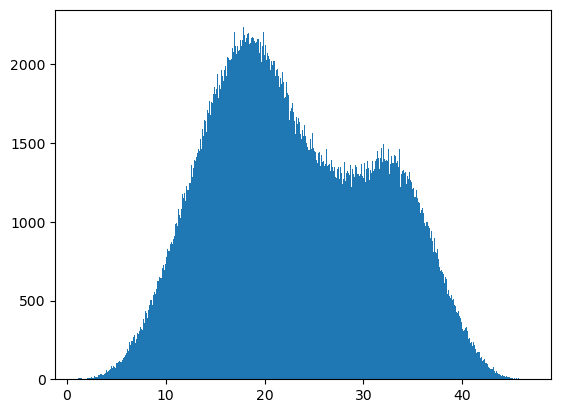

In [10]:
_ = plt.hist(orbit_discrete[:,2],1000)

In [22]:
#np.save('./results/lorenz_long_trajectory.npy',orbit)
#np.save('./results/lorenz_long_trajectory_0p01.npy',orbit_discrete)

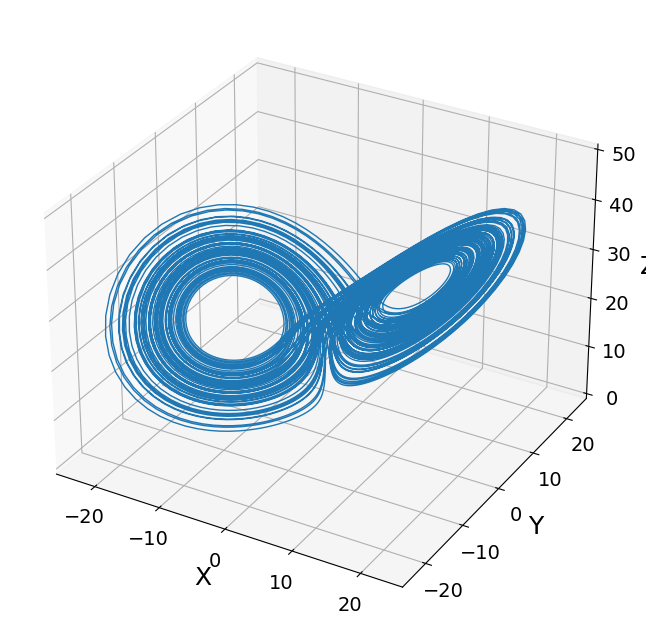

In [14]:
horizon_1 = 0
horizon_2 = 10000#2990

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(orbit_discrete[horizon_1:horizon_2,0], orbit_discrete[horizon_1:horizon_2,1], orbit_discrete[horizon_1:horizon_2,2], "-", linewidth=1)
#ax.plot(orbit_discrete_new[horizon_1:horizon_2,0], orbit_discrete_new[horizon_1:horizon_2,1], orbit_discrete_new[horizon_1:horizon_2,2], "--", linewidth=1)
ax.set_xlabel('X', fontsize=18)
ax.set_ylabel('Y', fontsize=18)
ax.set_zlabel('Z', fontsize=18)
plt.xlim(-25, 25)
plt.ylim(-25, 25)
ax.set_zlim(0, 50)  
ax.tick_params(labelsize=14)

# Save as PDF before showing the plot
#plt.savefig("orbit_plot.pdf", bbox_inches='tight')
plt.show()